# Fobench Basics
Welcome to the tutorial of the basic functionalities of Fobench. This notebook will guide you through the loading of data, preprocessing steps and visuals. Of course we can not go through every method in detail, so feel free to dive into the documentation if you want to know more. Here and there we will hint to more functionality to discover but for now we will stick to the basics.

In [1]:
import sys
sys.path.append('/home/joni/Dokumente/GEO4D/Software/fobench/')
from fobench.fiber import Fiber

The workhorse of Fobench is the `Fiber` class, it contains the actual fiber optic record with all its metadata and provides a lot of functionality to manipulate data in space and time. Let us go right ahead and load a file. We simply give the path to the file and we let Fobench know the manufacturer of the interrogator we used. In our case we will use data recorded on an Aragon Photonics HDAS system.

In [2]:
das = Fiber('./example_data/2024_07_11_05h15m16s_HDAS_2DRawData_Strain.h5', 'aragon')

Reading HDF5 file (Aragon Photonics Format)...


The following other manufacturers are supported in Fobench:

    - 'tmds' from 'silixa'
    - 'hdf5' from 'silixa'
    - 'hdf5' from 'febus'
    - 'hfd5' from 'terra15'
    - 'hdf5' from 'asn'
    - 'hdf5' from 'quantx'

First, we will have a look at the most important aquisition parameters of our file:

In [3]:
print(das)
#das.metadata() # for the full metadata


Instance of Fiber class
recording parameters:
-----------------------------------------------------------------
units                     = strain
start_time                = 2024-07-11T05:15:15.791536Z
end_time                  = 2024-07-11T05:16:15.791536Z
num_points                = 15000
total_channels            = 501
spatial_interval          = 1.0
sampling_frequency        = 250.0
gauge_length              = 6.0


We can see that the file contains only a single minute of strain data, lets concatenate a second file and convert into strain-rate after. 

In [4]:
das += Fiber('./example_data/2024_07_11_05h16m16s_HDAS_2DRawData_Strain.h5', 'aragon') # the += syntax just calls Fiber.concatenate
das.differentiate() # Fiber.integrate for integration of the data

Reading HDF5 file (Aragon Photonics Format)...


Our original sampling frequency is a bit too high, we will decimate the data to 50 Hz.

If we then check the aquisition parameters again, we can see that we now have two minutes of strain-rate data at 50 Hz

In [5]:
new_freq = 50
das.decimate(new_freq)
print(das)


Instance of Fiber class
recording parameters:
-----------------------------------------------------------------
units                     = strain-rate
start_time                = 2024-07-11T05:15:15.791536Z
end_time                  = 2024-07-11T05:17:15.791002Z
num_points                = 5978
total_channels            = 501
spatial_interval          = 1.0
sampling_frequency        = 50.0
gauge_length              = 6.0


The `Fiber` class stores the actual data in the `Fiber.data` attribute. This way we can easily access and extract it:

In [6]:
das.data
#das.get_data() # returns full data or data of a specific channel
#das.times # returns the time stamps for each sample in specified format

array([[-5.05701593e-07, -4.43409428e-07, -3.89642319e-07, ...,
        -2.66172304e-09,  2.66216876e-07,  4.95154280e-08],
       [ 6.54711691e-07,  6.16109753e-07,  1.00522968e-06, ...,
        -8.24444780e-08, -1.81719877e-08, -1.63707361e-07],
       [-4.14687086e-07, -4.66523376e-07,  8.97711739e-07, ...,
        -5.69622756e-08, -1.25831108e-07,  2.40222577e-08],
       ...,
       [-6.69255165e-09, -1.69031062e-07, -1.09115180e-07, ...,
        -1.13536034e-08,  3.56308949e-09, -1.68962164e-08],
       [ 8.82228047e-08,  4.73564115e-08,  1.20374217e-07, ...,
         7.79522659e-08,  1.10855586e-07,  1.05575880e-07],
       [-1.81449385e-08,  1.28641489e-07,  5.04923928e-08, ...,
        -6.19960596e-08, -1.32071017e-07, -6.94855845e-08]])

Most operations on the data are done inplace. Just in case we mess something up later on, at any point we can get a copy of the records current state with `Fiber.copy()`

In [7]:
backup_das = das.copy()

TypeError: h5py objects cannot be pickled

Before we have a look at the data, we should apply some basic preprocessing. Let us start with a simple bandpass filter between 0.1 and 20 Hz. We can check if the filter was applied successfully by looking at the list stored in `Fiber.processing`:

In [8]:
das.filter(f_type='bandpass', freq=(0.1, 20)) # other filter options are highpass, lowpass and bandstop. Fobench also provides more specialized filters such as median, Cheby and FIR-filters
das.processing

[{'instance creation': 'Thu Apr 10 12:03:58 2025'},
 {'differentiate': {'method': 'gradient', 'dim': 't'}},
 {'decimate': {'new_freq': 50, 'ftype': 'fir-remez'}},
 {'detrend': {'order': 1, 'dim': 't'}},
 {'demean': {'dim': 't'}},
 {'taper': {'frac': 0.05, 'dim': 't'}},
 {'filter': {'f_type': 'bandpass',
   'freq': (0.1, 20),
   'pre_process': True,
   'frac': 0.05,
   'order': 1,
   'options': {}}}]

The list keeps track of all preprocessing steps included in Fobench so that at any point we can go back and check which steps we took in what order. This is done by storing the methods name and all parameters it is called with.

We can see that before bandpass filtering the data was detrended, demeaned and tapered. That is because the filter function by default conviniently performs these steps by calling `Fiber.detrend()`, `Fiber.demean()` and `Fiber.taper()` before the actual filtering. Of course all these methods can be used individually and `filter` can be used with the `pre_process` parameter set to `False`.

Note also that most methods have additional parameters such as the removal of higher order polynomial trends by passing the `order` to `Fiber.detrend()`. A lot of methods can be applied in both space and time, this is determined by the `dim` parameter.


Now back to our data! Let us plot the record in both time and frequency domain:

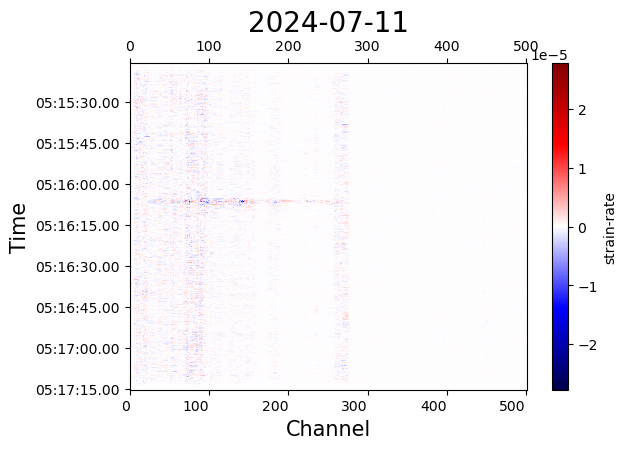

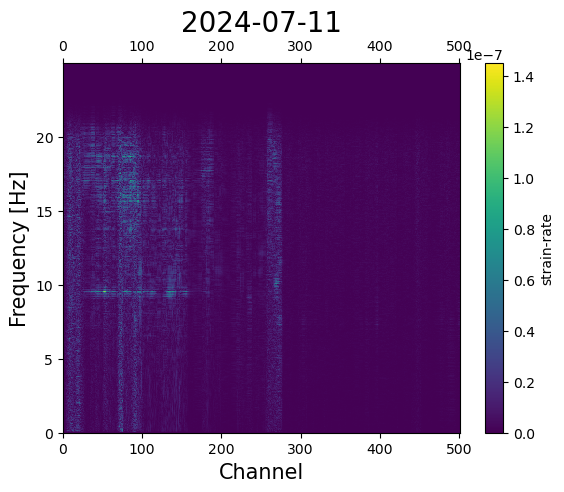

In [9]:
das.plot()
das.spectrogram()

It seems that we have recorded a small event! However it looks like towards the end of the cable we have no useful data anymore. We will trim the record and focus on the channels 20 to 280

In [10]:
das.restrict_channels((20, 280))
das.total_channels # number of channels in the record
# print(das.channels_num) # all channel numbers

261

Now that we have indentified the channels that we are interested in, the next time when we are loading data, we can retrieve only the part of interest. This can decrease the loading time significantly. We do that by simply passing the channel range to the Fiber class: 
```
file = './example_data/2024_07_11_05h15m16s_HDAS_2DRawData_Strain.h5'
manufacturer = 'aragon'
channels = [20, 280]
das = Fiber(file, manufacturer, range_ch=channels)
```
We can also trim the record around the time of the event and normalize to the absolute max of the record before plotting:

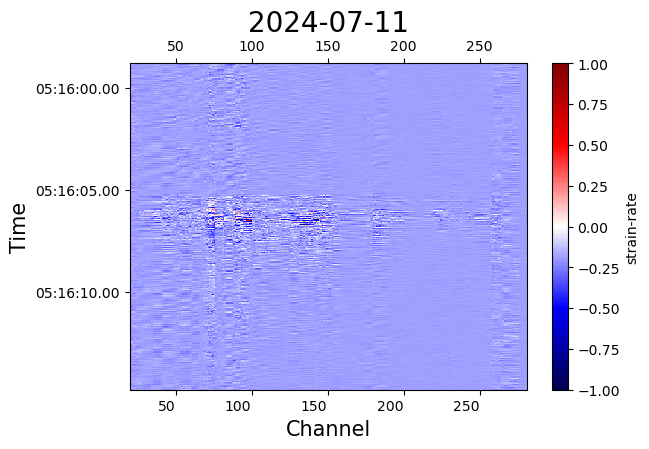

In [11]:
t0 = das.start_time + 43
tf = t0 + 16
das.trim(t0, tf)
das.normalize() #default is abolute max normalization, other options are trace max, running absolute mean and 1bit
das.plot()

We can look at a few channels in more detail, lets go for 100 - 110:

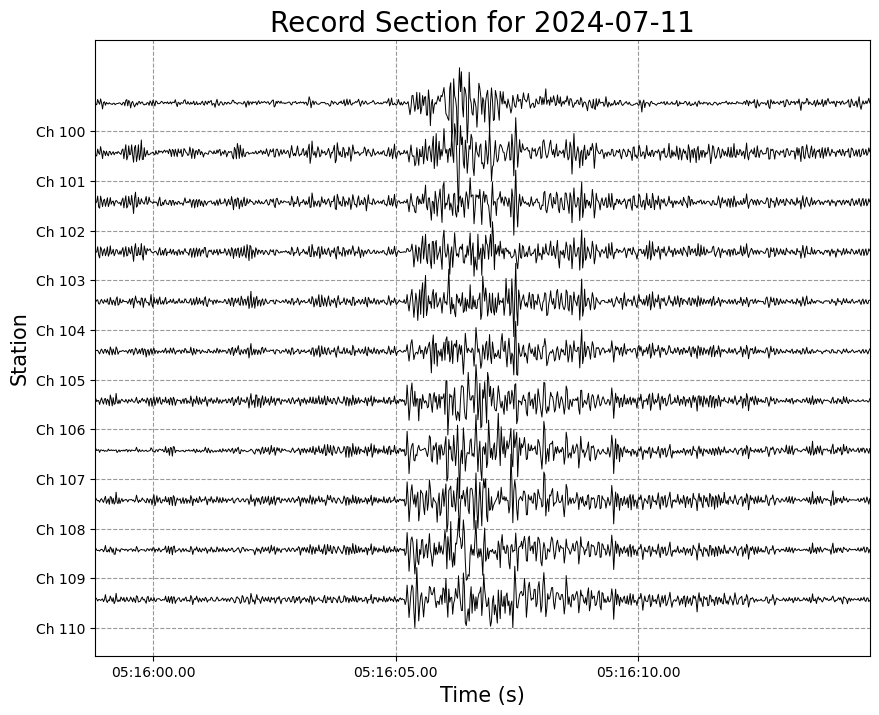

In [12]:
section = (100, 110)
das.plot_record_section(section)

We can plot a single channels waveform and the corresponding spectrogram and amplitude spectrum:

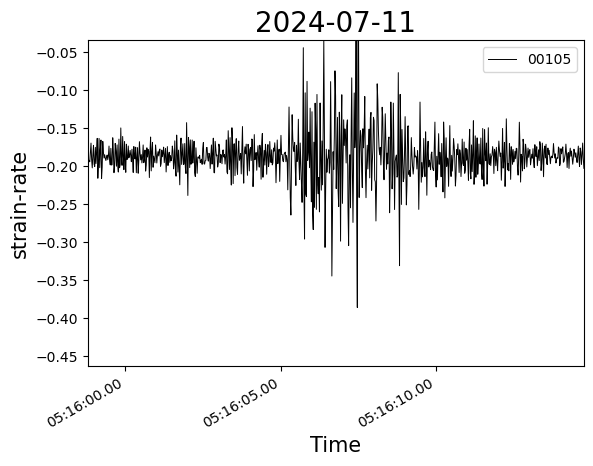

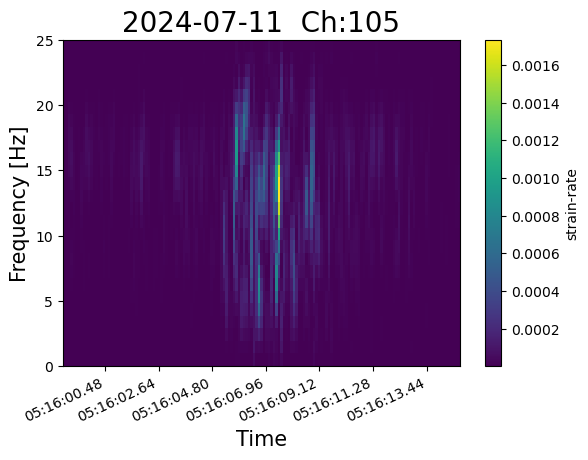

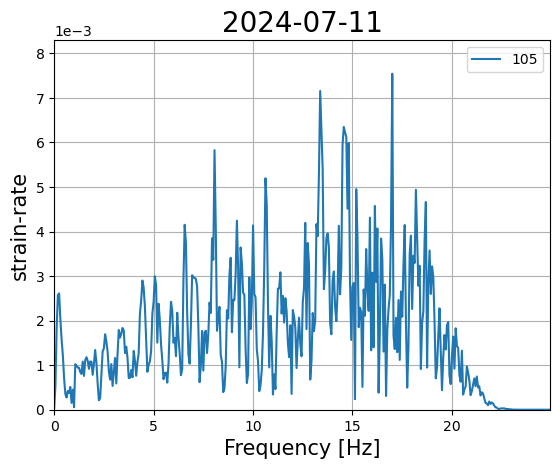

In [13]:
ch = 105
das.channel_plot(ch)
das.channel_spectrogram(ch)
das.spectrum(channels=ch)

A lot of methods have two plotting modes available, the default is 'mpl' which generates matplotlib plots. This is what we have been using so far. However, for larger datasets matplotlib tends to get very slow when generating plots. Thats where we can use the 'pyqt' mode which is especially useful for exploring a dataset effienciently. To use this, call the methods that offer Qt plotting with plot_mode='pyqt'. Be ware that these plots are not easily compatible with jupyter notebooks but can be called from other IDEs or a script in the terminal.